# Homework 2.1 — Group fixed effects

## tl;dr

The fitted common time slope is **0.009017**, matching **Q2: Option D**.
The group intercepts are **G1 = 0.078552**, **G2 = 0.589654**, and
**G3 = 0.269032**.

**Q1 has a wording mismatch.** Option D (**0.00850**) matches the slope
from a separate regression of G1 on time (**0.008498**). It does not match
the G1 fixed intercept in the requested common-slope model; none of the
Q1 choices matches that intercept. D is therefore the likely intended
choice, subject to this distinction.

## Context & Methods

Source: `homework_2.1.csv` in the project folder. G1, G2, and G3
are outcomes for three groups, and time is the common predictor.
Reshape the wide data into one row per group and time, then estimate

$$Y_{g,t} = \alpha_g + \beta\,time_t + \varepsilon_{g,t}.$$

The three group indicators estimate the intercepts at time zero.
Include all three indicators and time, with `fit_intercept=False`,
to avoid a redundant overall intercept. This still gives every group
its own intercept. A separate G1 regression is included only to resolve
the ambiguity in Q1.

### Key Assumptions

The requested model has a common linear time slope and constant group
offsets. No observations are removed or imputed. A trend in time is an
association; this regression alone does not establish causality.

Setup if packages are missing: `%pip install numpy pandas matplotlib scikit-learn`.
Keep the CSV in the project folder above `Homework Code`.

## Data

### 1. Setup and source checks

In [1]:
from pathlib import Path
import hashlib
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression

pd.set_option('display.precision', 6)
plt.rcParams.update({
    'figure.figsize': (9, 4.8), 'figure.dpi': 110,
    'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E5E7EB', 'axes.axisbelow': True,
    'text.color': '#1F2937', 'axes.labelcolor': '#1F2937',
})
BLUE, GOLD, DARK = '#2563EB', '#B7791F', '#374151'

def locate_csv(filename):
    # Works from the project folder, Homework Code, or Homework Code/HW2.
    candidates = [folder / filename for folder in (Path.cwd(), *Path.cwd().parents)]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f'Cannot find {filename}. Run from the project folder or one of its subfolders.'
    )

def show_table(frame, formats=None):
    display(frame.style.hide(axis='index').format(formats or {}, na_rep='—'))

In [2]:
DATA_PATH = locate_csv('homework_2.1.csv')
GROUPS = ['G1', 'G2', 'G3']
data = pd.read_csv(DATA_PATH)
required = ['time', *GROUPS]
if not set(required).issubset(data.columns):
    raise ValueError(f'Required columns: {required}')
if not all(pd.api.types.is_numeric_dtype(data[c]) for c in required):
    raise TypeError('All analysis columns must be numeric.')
if not np.isfinite(data[required].to_numpy()).all():
    raise ValueError('Analysis columns contain missing or infinite values.')
if data['time'].duplicated().any():
    raise ValueError('Expected one row per time value in the wide source.')

print(f'Source: {DATA_PATH.name}; rows: {len(data)}; missing values: 0')
print('SHA-256:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())
display(data.head())

Source: homework_2.1.csv; rows: 100; missing values: 0
SHA-256: e607ff912736bc83ebf18bae569d00302e468f71e400fa781872444b03c302a1


,time,G1,G2,G3
0,0,0.882026,1.441575,0.065409
1,1,0.210079,-0.163880,0.140310
2,2,0.509369,-0.115242,0.819830
3,3,1.150447,1.014698,0.607632
4,4,0.973779,-0.046562,0.610066


### 2. Reshape outcomes from wide to long

In [3]:
long_data = data.melt(
    id_vars='time', value_vars=GROUPS, var_name='group', value_name='Y'
)
assert len(long_data) == len(data) * len(GROUPS)
group_summary = long_data.groupby('group', sort=False).agg(
    observations=('Y', 'size'), mean_Y=('Y', 'mean'),
    first_time=('time', 'min'), last_time=('time', 'max')
).reset_index()
show_table(group_summary, {'mean_Y': '{:.6f}'})

group,observations,mean_Y,first_time,last_time
G1,100,0.524904,0,99
G2,100,1.036006,0,99
G3,100,0.715384,0,99


## Results

### 3. Estimate the three fixed intercepts and shared slope

In [4]:
indicators = pd.get_dummies(long_data['group'], dtype=float)[GROUPS]
design = indicators.assign(time=long_data['time'].to_numpy())
outcome = long_data['Y'].to_numpy()
model = LinearRegression(fit_intercept=False).fit(design, outcome)
coefficients = pd.Series(model.coef_, index=design.columns)
common_slope = coefficients['time']

coefficient_table = pd.DataFrame({
    'Term': ['G1 intercept', 'G2 intercept', 'G3 intercept', 'Common time slope'],
    'Estimate': model.coef_,
})
show_table(coefficient_table, {'Estimate': '{:.9f}'})
print(f'In-sample R²: {model.score(design, outcome):.6f}')

Term,Estimate
G1 intercept,0.078551946
G2 intercept,0.589654423
G3 intercept,0.269031808
Common time slope,0.009017213


In-sample R²: 0.311047


### 4. Check the estimates using within-group demeaning

In [5]:
within_time = long_data['time'] - long_data.groupby('group')['time'].transform('mean')
within_y = long_data['Y'] - long_data.groupby('group')['Y'].transform('mean')
within_slope = np.dot(within_time, within_y) / np.dot(within_time, within_time)
group_means = long_data.groupby('group')[['time', 'Y']].mean().loc[GROUPS]
recovered_intercepts = group_means['Y'] - within_slope * group_means['time']
np.testing.assert_allclose(within_slope, common_slope, atol=1e-12)
np.testing.assert_allclose(recovered_intercepts, coefficients[GROUPS], atol=1e-12)
print(f'Within-group slope: {within_slope:.9f}; agrees with the indicator regression.')

Within-group slope: 0.009017213; agrees with the indicator regression.


### 5. View the common trend and group offsets

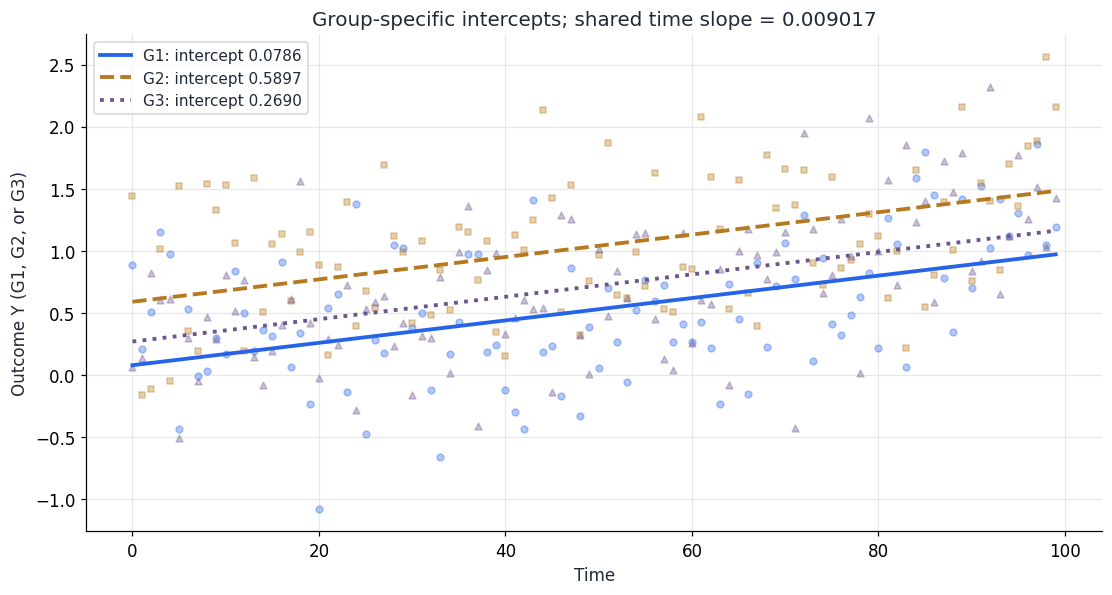

In [6]:
colors = {'G1': BLUE, 'G2': GOLD, 'G3': '#6B558E'}
markers = {'G1': 'o', 'G2': 's', 'G3': '^'}
styles = {'G1': '-', 'G2': '--', 'G3': ':'}
times = np.linspace(data['time'].min(), data['time'].max(), 100)
fig, ax = plt.subplots(figsize=(10, 5.3), layout='constrained')
for group in GROUPS:
    ax.scatter(data['time'], data[group], color=colors[group],
               marker=markers[group], s=20, alpha=0.35)
    ax.plot(times, coefficients[group] + common_slope * times,
            color=colors[group], linestyle=styles[group], linewidth=2.5,
            label=f'{group}: intercept {coefficients[group]:.4f}')
ax.set(title=f'Group-specific intercepts; shared time slope = {common_slope:.6f}',
       xlabel='Time', ylabel='Outcome Y (G1, G2, or G3)')
ax.legend(frameon=True, fontsize=10)
plt.show()

Each fitted line has the same slope. The vertical separation between
lines represents the estimated group offsets; observed outcomes also
vary around those fitted lines.

### 6. Resolve the Question 1 wording

A separate regression gives G1 its own time slope. This is a different
parameter from G1's fixed intercept in the shared-slope model above.

In [7]:
individual_fits = []
for group in GROUPS:
    separate = LinearRegression().fit(data[['time']], data[group])
    individual_fits.append({
        'Group': group, 'Separate intercept': separate.intercept_,
        'Separate time slope': separate.coef_[0],
    })
individual_table = pd.DataFrame(individual_fits)
g1_separate_slope = individual_table.loc[0, 'Separate time slope']
show_table(individual_table, {
    'Separate intercept': '{:.6f}', 'Separate time slope': '{:.9f}'
})
print(f'Q1 Option D (0.00850) matches the separate G1 slope: {g1_separate_slope:.9f}')
print(f'G1 fixed intercept with a common slope: {coefficients["G1"]:.9f} (not offered).')
print(f'Q2 Option D (0.009017) matches the common slope: {common_slope:.9f}')

Group,Separate intercept,Separate time slope
G1,0.104236,0.008498349
G2,0.685523,0.007080468
G3,0.147479,0.011472823


Q1 Option D (0.00850) matches the separate G1 slope: 0.008498349
G1 fixed intercept with a common slope: 0.078551946 (not offered).
Q2 Option D (0.009017) matches the common slope: 0.009017213


## Takeaways

- **Q1: likely Option D (0.00850)** if the intended parameter is G1's
  separately fitted time slope. The literal fixed-intercept answer is
  **0.078552**, and none of the choices matches it.
- **Q2: Option D (0.009017)** for the common time slope.

The indicator regression and within-group calculation agree. The
Question 1 discrepancy is a difference in parameter definition, not
ordinary rounding.

### Reproducibility

In [8]:
print('Python', platform.python_version())
for package in ['numpy', 'pandas', 'matplotlib', 'scikit-learn']:
    print(package, importlib.metadata.version(package))

Python 3.13.5
numpy 2.4.1
pandas 3.0.0
matplotlib 3.10.8
scikit-learn 1.8.0
